<a href="https://colab.research.google.com/github/GhaziFadhlullah/ImageProcessing2026/blob/main/histogram_enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files


In [12]:
# 1. Upload gambar
uploaded = files.upload()
# membaca citra
image = cv2.imread('kopi.jpeg')

Saving kopi.jpeg to kopi (2).jpeg


Grayscale Image


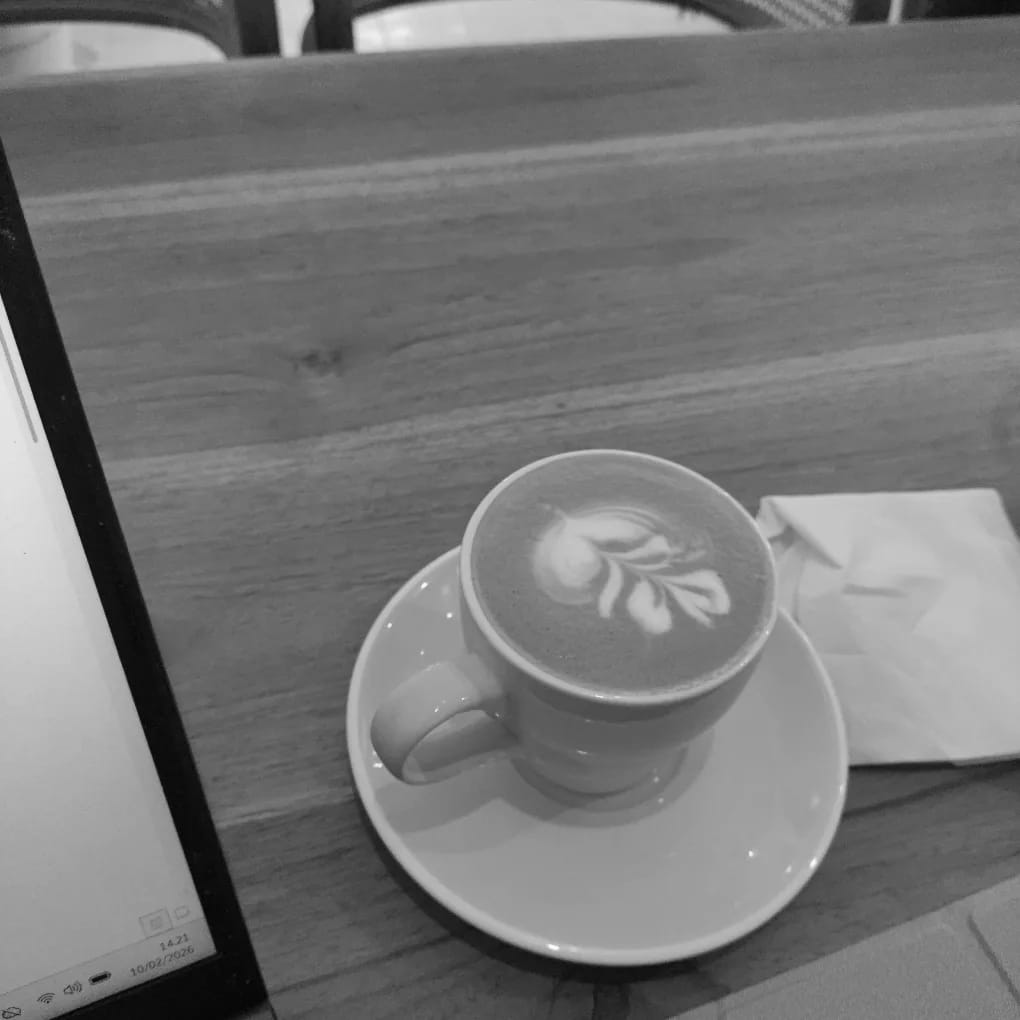

In [13]:
# 2. Konversi ke grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Grayscale Image")
cv2_imshow(gray)

# ukuran citra
rows, cols = gray.shape


In [14]:
# 3. Menghitung Histogram
histogram = np.zeros(256)

for i in range(rows):
    for j in range(cols):
        pixel = gray[i, j]
        histogram[pixel] += 1

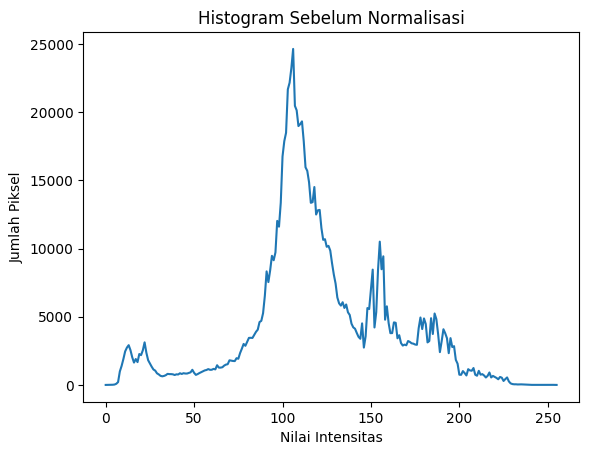

In [15]:
# 4. Histogram Sebelum Normalisasi
plt.figure()
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.plot(histogram)
plt.show()

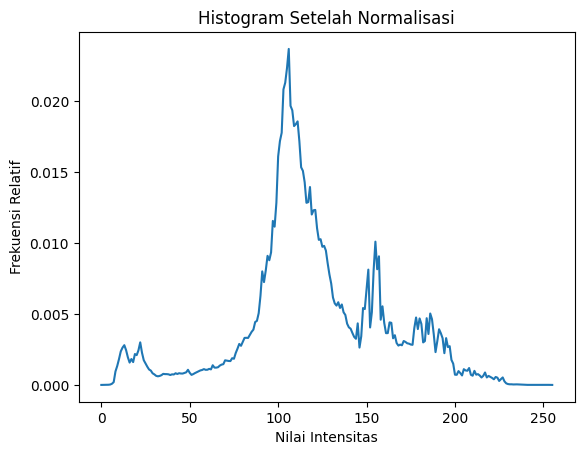

In [16]:
# 5. Normalisasi Histogram
total_pixels = rows * cols
hist_normalized = histogram / total_pixels

plt.figure()
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Frekuensi Relatif")
plt.plot(hist_normalized)
plt.show()

In [17]:
# 6. Menghitung CDF
cdf = np.zeros(256)
cdf[0] = hist_normalized[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + hist_normalized[i]

In [18]:
# 7. Mapping Intensitas Baru
mapping = np.round(cdf * 255).astype(np.uint8)

Original Image


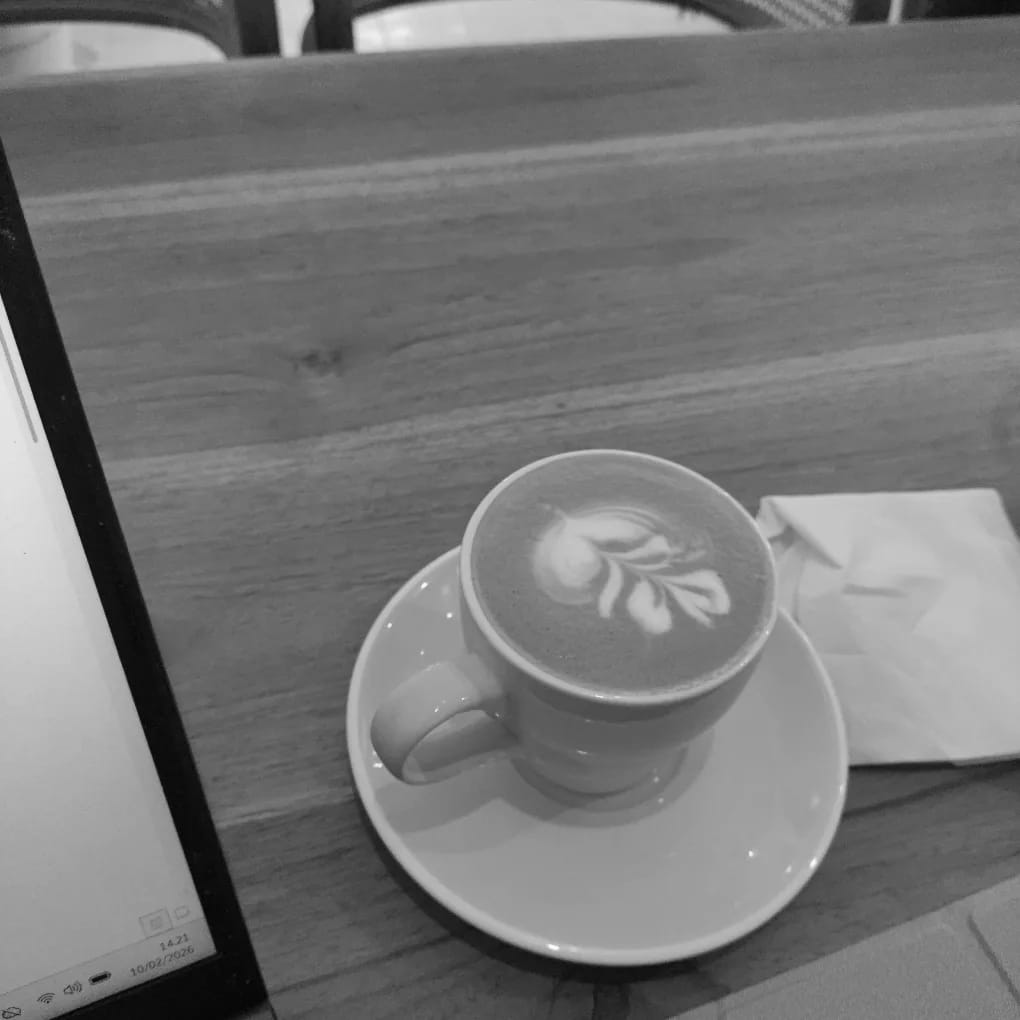

Equalized Image


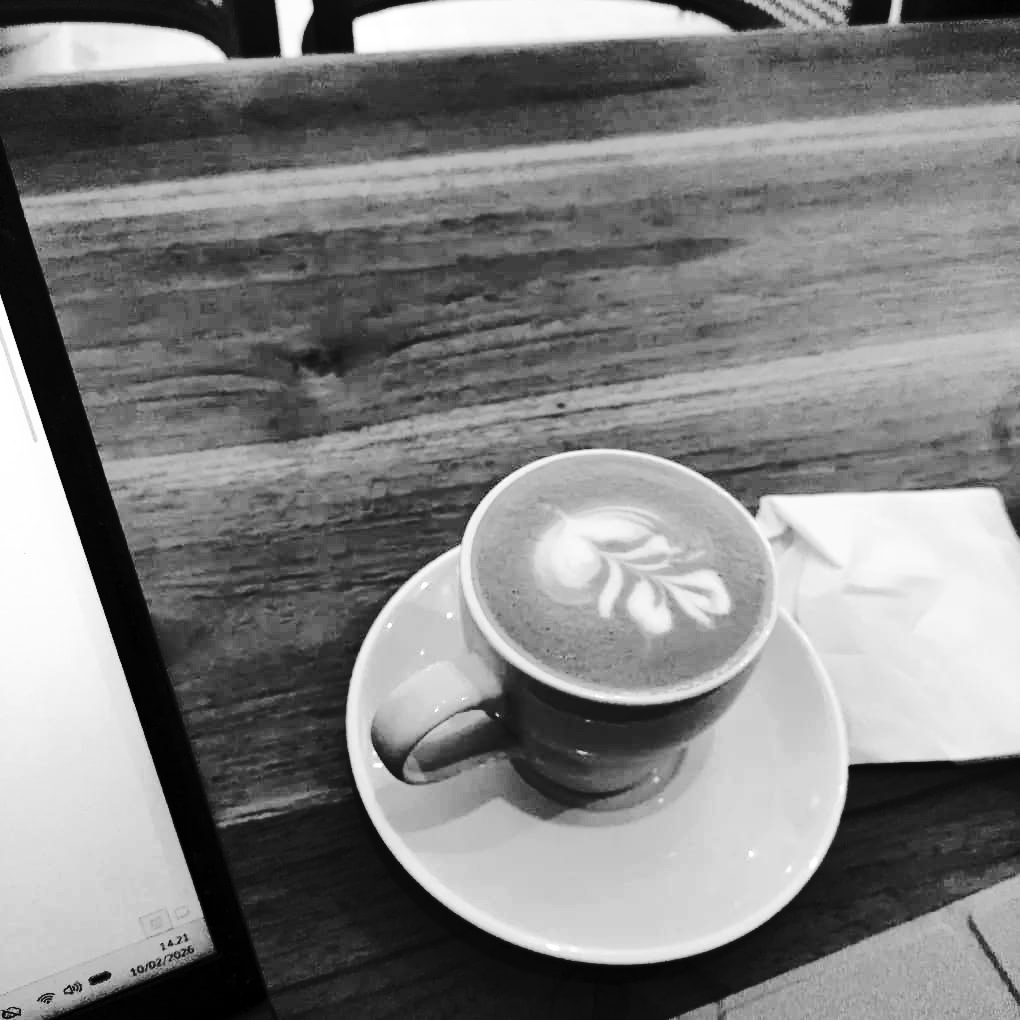

In [19]:
# 8. Histogram Equalization
equalized = np.zeros_like(gray)

for i in range(rows):
    for j in range(cols):
        equalized[i,j] = mapping[gray[i,j]]

print("Original Image")
cv2_imshow(gray)

print("Equalized Image")
cv2_imshow(equalized)


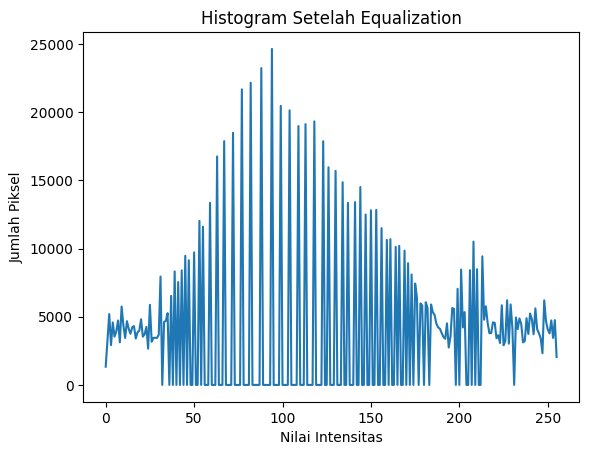

In [20]:
# 9. Histogram Setelah Equalization
hist_equalized = np.zeros(256)

for i in range(rows):
    for j in range(cols):
        hist_equalized[equalized[i,j]] += 1

plt.figure()
plt.title("Histogram Setelah Equalization")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.plot(hist_equalized)
plt.show()